# Завантаження та попередня обробка даних

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

np.random.seed(28)

# завант датасет
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("перші 5 рядків датасету")
print(df.head())
print()

# кількість рядків, типи даних, non-null значення
print("загальна інформація про дані")
print(df.info())
print()

# кількість пропущених значень у кожному стовпці
print("пропущені значення до обробки")
print(df.isnull().sum())
print()

# запов пропущені значення медіаною
df["Age"] = df["Age"].fillna(df["Age"].median())

# запов пропущені значення посадки модою
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# encoder для перетворення категоріальних ознак у числовий формат
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

# кодуємо стать
df["Sex"] = le_sex.fit_transform(df["Sex"])

# кодуємо порт посадки
df["Embarked"] = le_embarked.fit_transform(df["Embarked"])

# список ознак, які будуть використовуватись для класифікації
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

# X - матриця ознак, y - цільова змінна
X = df[features]
y = df["Survived"]

print("пропущені значення після обробки")
print(X.isnull().sum())
print()

print("розмір матриці ознак і цільової змінної")
print("X:", X.shape)
print("y:", y.shape)
print()

print("розподіл класів у цільовій змінній")
print(y.value_counts())
print(y.value_counts(normalize = True).round(3))

перші 5 рядків датасету
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.

# Поділ даних на навчальну та тестову вибірки

In [ ]:
# поділяємо дані на train і test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 28, stratify = y)

# виводимо розміри отриманих частин вибірки
print('розміри навчальної та тестової вибірок')
print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('y_train:', y_train.shape)
print('y_test: ', y_test.shape)
print()

# перевіряєм чи зберігся баланс класів після поділу
print('розподіл класів у навчальній вибірці')
print(y_train.value_counts(normalize = True).round(3))
print()

print('розподіл класів у тестовій вибірці')
print(y_test.value_counts(normalize = True).round(3))


розміри навчальної та тестової вибірок
X_train: (712, 7)
X_test:  (179, 7)
y_train: (712,)
y_test:  (179,)

розподіл класів у навчальній вибірці
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64

розподіл класів у тестовій вибірці
Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


# Побудова класифікатора на основі дерев рішень

In [ ]:
# модель дерева рішень
clf = DecisionTreeClassifier(criterion = 'gini', max_depth = 5, min_samples_split = 10, min_samples_leaf = 5, random_state = 28 )

# навчаєм модель
clf.fit(X_train, y_train)

# отримуємо передбачені класи для тестової вибірки
y_pred = clf.predict(X_test)

# складність побудованого дерева
print('--- параметри побудованого дерева ---')
print('глибина дерева:', clf.get_depth())
print('кількість листків:', clf.get_n_leaves())
print('кількість вузлів:', clf.tree_.node_count)
print()

# кілька прикладів прогнозу поруч із реальними значеннями
comparison = pd.DataFrame({'реальний_клас': y_test.values[:10], 'прогноз_моделі': y_pred[:10] })
print('--- перші 10 прогнозів ---')
print(comparison)

# правила дерева
print('\n--- текстові правила дерева ---')
print(export_text(clf, feature_names = features))


--- параметри побудованого дерева ---
глибина дерева: 5
кількість листків: 24
кількість вузлів: 47

--- перші 10 прогнозів ---
   реальний_клас  прогноз_моделі
0              1               0
1              0               0
2              1               1
3              0               0
4              0               0
5              1               0
6              0               0
7              0               0
8              1               1
9              0               1

--- текстові правила дерева ---
|--- Sex <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 27.50
|   |   |   |--- Age <= 24.50
|   |   |   |   |--- Age <= 7.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Age >  7.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- Age >  24.50
|   |   |   |   |--- class: 1
|   |   |--- Age >  27.50
|   |   |   |--- Age <= 43.50
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  43.50
|   |   |   |   |--- Fare <= 34.16
|   |   |   |   |   |--- class: 1
|

# Оцінювання якості класифікації

--- основні метрики класифікації ---
accuracy:  0.7598
precision: 0.7708
recall:    0.5362
f1-score:  0.6325

--- confusion matrix ---
[[99 11]
 [32 37]]

tn - правильно передбачено клас 0: 99
fp - помилково передбачено клас 1: 11
fn - помилково передбачено клас 0: 32
tp - правильно передбачено клас 1: 37

--- classification report ---
              precision    recall  f1-score   support

    не вижив       0.76      0.90      0.82       110
       вижив       0.77      0.54      0.63        69

    accuracy                           0.76       179
   macro avg       0.76      0.72      0.73       179
weighted avg       0.76      0.76      0.75       179



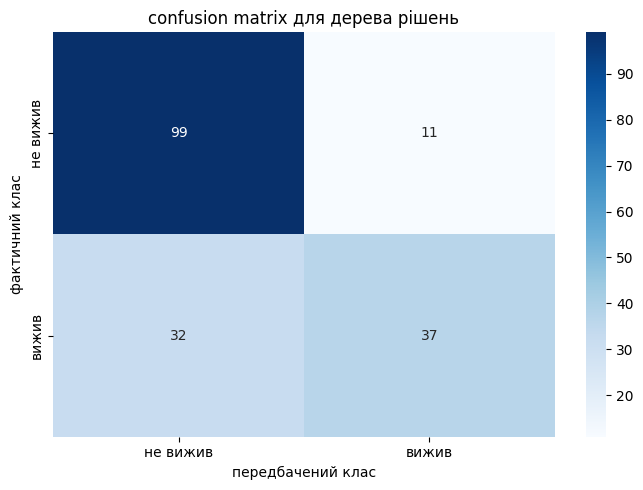

--- баланс класів у початковому датасеті ---
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [ ]:
# основні метрики класифікації
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('--- основні метрики класифікації ---')
print(f'accuracy:  {accuracy:.4f}')
print(f'precision: {precision:.4f}')
print(f'recall:    {recall:.4f}')
print(f'f1-score:  {f1:.4f}')
print()

# матриця невідповідностей
cm = confusion_matrix(y_test, y_pred)

print('--- confusion matrix ---')
print(cm)
print()

# розкладаємо матрицю на tn, fp, fn, tp для бінарної класифікації
tn, fp, fn, tp = cm.ravel()
print('tn - правильно передбачено клас 0:', tn)
print('fp - помилково передбачено клас 1:', fp)
print('fn - помилково передбачено клас 0:', fn)
print('tp - правильно передбачено клас 1:', tp)
print()

# детальний classification_report по кожному класу
print('--- classification report ---')
print(classification_report(y_test, y_pred, target_names=['не вижив', 'вижив']))

# confusion matrix як теплова карта
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels=['не вижив', 'вижив'],  yticklabels=['не вижив', 'вижив'])
plt.title('confusion matrix для дерева рішень')
plt.xlabel('передбачений клас')
plt.ylabel('фактичний клас')
plt.tight_layout()
plt.show()

print('--- баланс класів у початковому датасеті ---')
print(y.value_counts())
print(y.value_counts(normalize = True).round(3))


# Інтерпретація моделі

--- важливість ознак ---
     ознака  важливість
1       Sex    0.579168
0    Pclass    0.165496
5      Fare    0.136735
2       Age    0.085624
3     SibSp    0.027713
6  Embarked    0.005264
4     Parch    0.000000



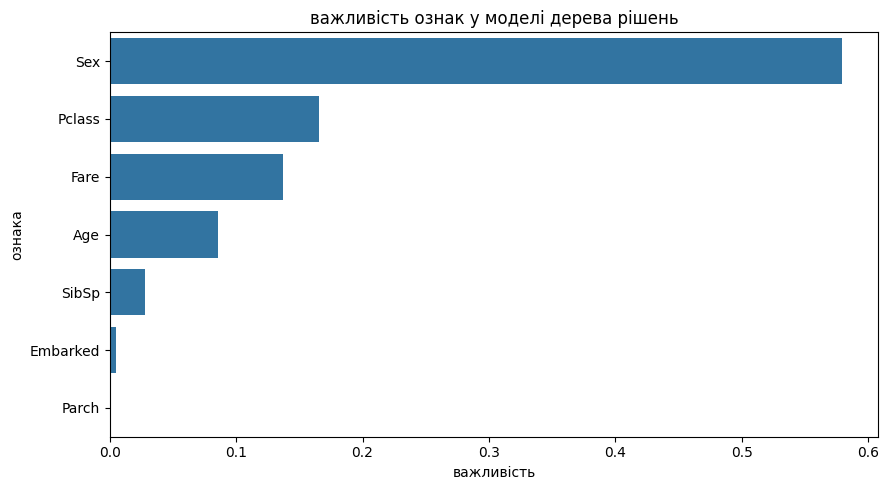

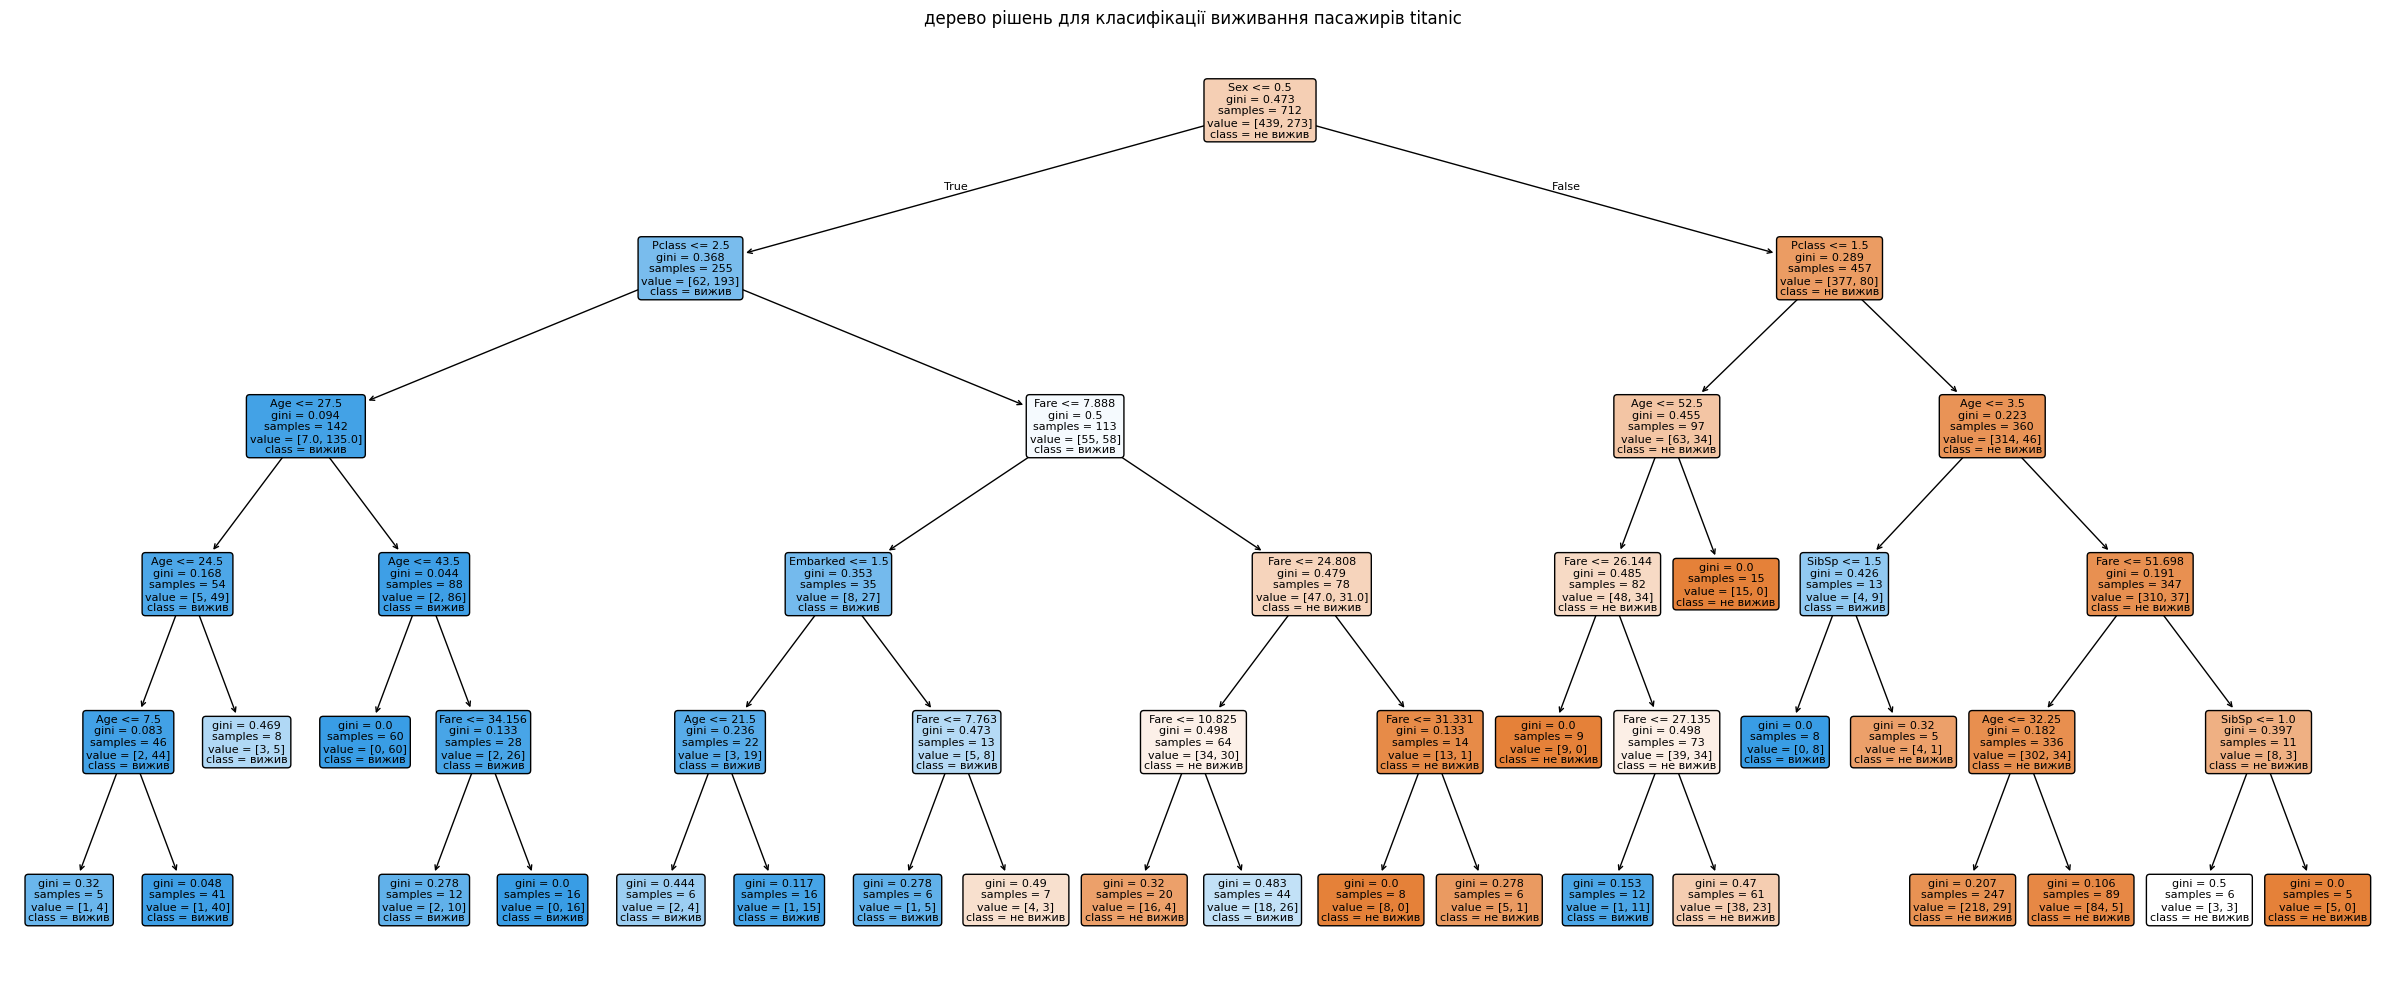

найважливіша ознака: Sex, важливість: 0.5792


In [ ]:
# важливість ознак із навченої моделі
importances = clf.feature_importances_

# таблиця назвами ознак та їх важливістю
feature_importance_df = pd.DataFrame({ 'ознака': features, 'важливість': importances}).sort_values(by = 'важливість', ascending = False)

print('--- важливість ознак ---')
print(feature_importance_df)
print()

# візуалізуємо важливість ознак
plt.figure(figsize = (9, 5))
sns.barplot(data = feature_importance_df, x = 'важливість', y = 'ознака')
plt.title('важливість ознак у моделі дерева рішень')
plt.xlabel('важливість')
plt.ylabel('ознака')
plt.tight_layout()
plt.show()

# візуалізуємо саме дерево рішень
plt.figure(figsize=(24, 10))
plot_tree(clf, feature_names = features, class_names = ['не вижив', 'вижив'], filled = True, rounded = True, fontsize = 8, impurity = True, precision = 3 )
plt.title('дерево рішень для класифікації виживання пасажирів titanic')
plt.tight_layout()
plt.show()

# найважливіша ознака
best_feature = feature_importance_df.iloc[0]['ознака']
best_value = feature_importance_df.iloc[0]['важливість']
print(f'найважливіша ознака: {best_feature}, важливість: {best_value:.4f}')
